In [9]:
# DBSCAN Algorithm for Automatic Emergency Braking (AEB) for cars with object classifier and calculation of Time To Collision (TTC)
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

print("Necessary Modules imported")

Necessary Modules imported


In [10]:
# Configuration
np.random.seed(42)           # 42 reference for reproducibility, blank or other number for random input
FRAME_RATE = 20.0            # 20 Hz  frame frequency
DT = 1.0 / FRAME_RATE        # time per frame in s

MAX_BRAKE_DISTANCE = 18.0    # maximum horizontal distance of detected object in m to activate AEB
LANE_WIDTH_HALF    = 2.0     # maximum vertical distance of detected object in m to activate AEB
TIME_TO_COLLISION_THRESHOLD = 3.0  # typical AEB TTC threshold in s

In [11]:
# 1. Generate CURRENT frame point cloud
vehicle_points = np.random.normal(loc=[10.0, 0.0], scale=[1.5, 0.6], size=(50, 2))
pedestrian_points = np.random.normal(loc=[25.0, 4.0], scale=[0.5, 1.0], size=(20, 2))
noise_points = np.random.normal(loc=0.0, scale=15.0, size=(120, 2))

point_cloud = np.vstack([vehicle_points, pedestrian_points, noise_points])
print(f"Total points: {len(point_cloud)}")


Total points: 190


In [12]:
# 2. Synthetic PREVIOUS frame centroids (for velocity estimation demo)
# In real system these would come from tracked objects / previous clustering
prev_vehicle_centroid = np.array([10.8, 0.15])   # approaching ego + slight right drift
prev_pedestrian_centroid = np.array([24.7, 3.85])  # slowly moving left & forward

In [13]:
# 3. DBSCAN clustering on current frame
eps = 1.8
min_samples = 5

db = DBSCAN(eps=eps, min_samples=min_samples).fit(point_cloud)
labels = db.labels_

unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = np.sum(labels == -1)

print(f"\nDetected clusters: {n_clusters}    Noise points: {n_noise} ({n_noise/len(point_cloud)*100:.1f}%)")
# ────────────────────────────────────────────────
# Simple rule-based classifier
def classify_cluster(f):
    """
    f: dict with keys: n_points, width_x, width_y, approx_area, point_density, centroid_y
    Returns: class_name, vehicle_score, pedestrian_score
    """
    score_v = 0
    score_p = 0

    # Area (larger = vehicle)
    if f['approx_area'] > 12:   score_v += 2
    elif f['approx_area'] < 8:  score_p += 1

    # Aspect ratio X/Y (elongated horizontally = vehicle)
    ar = f['width_x'] / f['width_y'] if f['width_y'] != 0 else 999
    if ar > 2.0:                score_v += 2
    elif ar < 1.0:              score_p += 2

    # Point count (more points = vehicle)
    if f['n_points'] > 30:      score_v += 2
    elif f['n_points'] < 15:    score_p += 1

    # Point density (denser = vehicle)
    if f['point_density'] > 3.0: score_v += 1
    elif f['point_density'] < 2.5: score_p += 1

    # Lateral position (more centered = vehicle)
    if abs(f['centroid_y']) < 1.5: score_v += 1
    else:                           score_p += 1

    if score_v > score_p:
        return "Vehicle", score_v, score_p
    elif score_p > score_v:
        return "Pedestrian", score_v, score_p
    else:
        return "Unknown", score_v, score_p


Detected clusters: 2    Noise points: 118 (62.1%)


In [14]:
# 4. Extract cluster info and estimate velocity and classify objects
cluster_info = []

for cluster_id in sorted([lbl for lbl in unique_labels if lbl != -1]):
    mask = (labels == cluster_id)
    pts = point_cloud[mask]
    if len(pts) < min_samples:
        continue

    centroid_now = np.mean(pts, axis=0)
    if centroid_now[0]<=0:                                # Eliminate clustering of noise points behind the ego vehicle
      continue
    bbox_min = np.min(pts, axis=0)
    bbox_max = np.max(pts, axis=0)

    # Size features for classification
    width_x = bbox_max[0] - bbox_min[0]
    width_y = bbox_max[1] - bbox_min[1]
    approx_area = width_x * width_y
    point_density = len(pts) / approx_area if approx_area > 0 else 0

    # --- Velocity estimation ---
    # For demo: match clusters manually by proximity / semantics
    # In real system: use tracking (Kalman, SORT, ByteTrack, etc.)
    if cluster_id == 0:  # vehicle cluster
        centroid_prev = prev_vehicle_centroid
    elif cluster_id == 1:  # pedestrian
        centroid_prev = prev_pedestrian_centroid
    else:
        centroid_prev = None

    if centroid_prev is not None:
        delta_pos = centroid_now - centroid_prev
        velocity = delta_pos / DT           # m/s  (vx, vy)
        speed = np.linalg.norm(velocity)
        # Approximate range rate (negative = approaching)
        range_now = np.linalg.norm(centroid_now)
        range_rate = velocity[0] * (centroid_now[0] / range_now)   # projected towards ego
    else:
        velocity = np.array([np.nan, np.nan])
        speed = np.nan
        range_rate = np.nan

    # Classify the cluster
    features = {
        'n_points': len(pts),
        'width_x': width_x,
        'width_y': width_y,
        'approx_area': approx_area,
        'point_density': point_density,
        'centroid_y': centroid_now[1]
    }
    cls, sv, sp = classify_cluster(features)

    # Store everything
    cluster_info.append({
        'id': cluster_id,
        'centroid': centroid_now,
        'points': len(pts),
        'velocity_m_s': velocity,
        'speed_m_s': speed,
        'range_rate_m_s': range_rate,
        'width_x': width_x,
        'width_y': width_y,
        'approx_area': approx_area,
        'point_density': point_density,
        'classification': cls,
        'scores': (sv, sp)
    })

    # Print cluster details
    print(f"\nObject {cluster_id}:")
    print(f"  Centroid:     ({centroid_now[0]:.2f}, {centroid_now[1]:.2f}) m")
    print(f"  Velocity:     ({velocity[0]:+.1f}, {velocity[1]:+.1f}) m/s    speed = {speed:.1f} m/s")
    print(f"  Range rate:   {range_rate:+.1f} m/s   (negative = closing)")
    print(f"  Points:       {len(pts)}")
    print(f"  BBox X:       {bbox_min[0]:.1f} – {bbox_max[0]:.1f} m")
    print(f"  BBox Y:       {bbox_min[1]:.1f} – {bbox_max[1]:.1f} m")
    print(f"  Classified as: {cls}  (V:{sv} vs P:{sp})")



Object 0:
  Centroid:     (9.74, -0.06) m
  Velocity:     (-21.1, -4.3) m/s    speed = 21.6 m/s
  Range rate:   -21.1 m/s   (negative = closing)
  Points:       51
  BBox X:       6.1 – 12.4 m
  BBox Y:       -1.2 – 1.1 m
  Classified as: Vehicle  (V:8 vs P:0)

Object 1:
  Centroid:     (25.02, 4.14) m
  Velocity:     (+6.3, +5.9) m/s    speed = 8.6 m/s
  Range rate:   +6.2 m/s   (negative = closing)
  Points:       21
  BBox X:       24.0 – 26.5 m
  BBox Y:       2.6 – 6.5 m
  Classified as: Pedestrian  (V:0 vs P:4)



AEB evaluation (with TTC check):
  Cluster 0 (Vehicle): dist=9.7m  TTC≈0.5s  range_rate=-21.1m/s
  → AEB TRIGGERED by Vehicle (TTC 0.5s < 3.0s)

Final AEB decision: 1   (1 = BRAKE, 0 = no action)


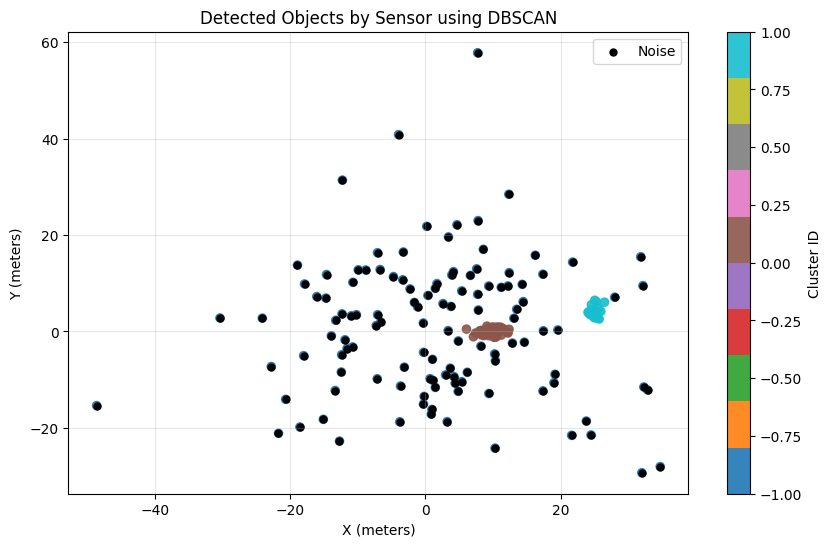

In [15]:
# 5. AEB logic with velocity consideration
aeb_active = 0

print("\nAEB evaluation (with TTC check):")
for obj in cluster_info:
    x, y = obj['centroid']
    vx, vy = obj['velocity_m_s']
    range_rate = obj['range_rate_m_s']
    cls = obj['classification']

    if x <= 0 or abs(y) > LANE_WIDTH_HALF:
        continue  # behind or clearly out of lane

    dist = x  # simplified longitudinal distance

    if dist > MAX_BRAKE_DISTANCE:
        continue

    # Time-to-collision approximation (using range rate)
    if range_rate < -0.5:  # only if approaching
        ttc = dist / -range_rate if range_rate != 0 else float('inf')
    else:
        ttc = float('inf')

    print(f"  Cluster {obj['id']} ({cls}): dist={dist:.1f}m  TTC≈{ttc:.1f}s  range_rate={range_rate:+.1f}m/s")

    if dist <= MAX_BRAKE_DISTANCE and ttc < TIME_TO_COLLISION_THRESHOLD:
        aeb_active = 1
        print(f"  → AEB TRIGGERED by {cls} (TTC {ttc:.1f}s < {TIME_TO_COLLISION_THRESHOLD}s)")
        break

print(f"\nFinal AEB decision: {aeb_active}   (1 = BRAKE, 0 = no action)")

# ────────────────────────────────────────────────
# Object Detection Visualization
plt.figure(figsize=(10, 6))
scatter = plt.scatter(point_cloud[:, 0], point_cloud[:, 1],
                      c=labels, cmap='tab10', s=35, alpha=0.9)
plt.scatter(point_cloud[labels == -1, 0], point_cloud[labels == -1, 1],
            c='black', s=25, label='Noise')
plt.title('Detected Objects by Sensor using DBSCAN')
plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Cluster ID')
plt.show()


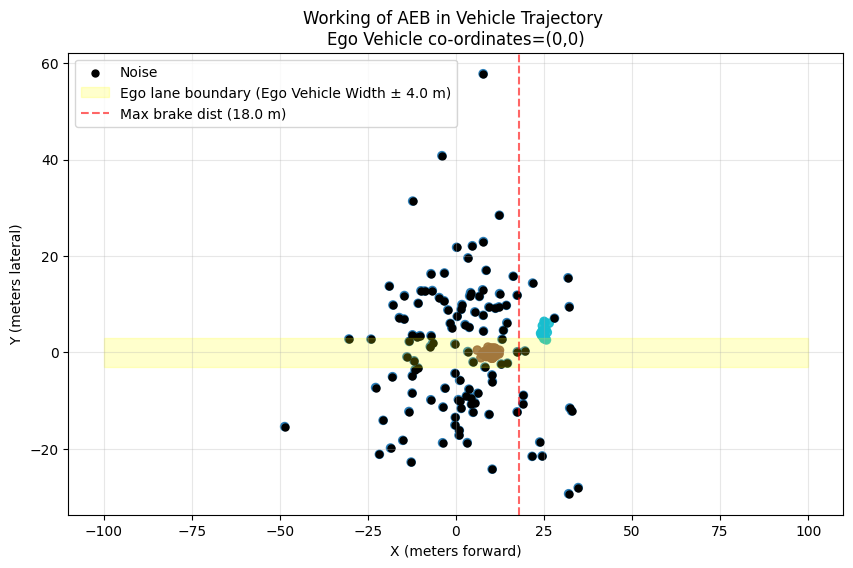

In [16]:
# 6. AEB Visualization showing vehicle travel path
plt.figure(figsize=(10, 6))
plt.scatter(point_cloud[:, 0], point_cloud[:, 1],
            c=labels, cmap='tab10', s=35, alpha=0.9)
plt.scatter(point_cloud[labels == -1, 0], point_cloud[labels == -1, 1],
            c='black', s=25, label='Noise')

# Lane boundaries
plt.fill_betweenx(y=[-3, 3], x1=-100, x2=100,
            color='yellow', alpha=0.2, label='Ego lane boundary (Ego Vehicle Width ± 4.0 m)')

plt.axvline(x=MAX_BRAKE_DISTANCE, color='red', linestyle='--', alpha=0.6,
            label=f'Max brake dist ({MAX_BRAKE_DISTANCE} m)')

plt.title('Working of AEB in Vehicle Trajectory \nEgo Vehicle co-ordinates=(0,0)')
plt.xlabel('X (meters forward)')
plt.ylabel('Y (meters lateral)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
